# 가중치 초기화
기울기 소실 문제 해결을 위함

--> 가중치 감소(weight decay) 시키는 방향으로 문제 해결

```
0.01 * np.random.randn(10, 100)
```

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [128]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def ReLU(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

In [129]:
input_data = np.random.randn(1000, 100)
node_num = 100
hidden_layer_size = 5
activations = {}

x = input_data

def get_activation(hidden_layer_size, x, w, a_func=sigmoid):
    for i in range(hidden_layer_size):
        if i != 0:
            x = activations[i - 1]

        a = np.dot(x, w)

        z = a_func(a)

        activations[i] = z
    return activations

In [130]:
w = np.random.randn(node_num, node_num) * 1
z = sigmoid
activations = get_activation(hidden_layer_size, x, w, z)

In [131]:
activations

{0: array([[5.87830662e-07, 9.98662928e-01, 9.98695766e-01, ...,
         5.55871652e-01, 7.02571314e-03, 1.75838864e-05],
        [9.99839200e-01, 4.86418403e-01, 9.99996972e-01, ...,
         3.83695313e-04, 2.53909630e-06, 9.99954864e-01],
        [4.42073051e-02, 4.76907761e-07, 4.38978006e-01, ...,
         4.42909557e-04, 9.99999884e-01, 9.99953765e-01],
        ...,
        [4.01934232e-01, 5.96091319e-08, 9.99975377e-01, ...,
         2.72402668e-07, 9.96466291e-01, 1.28427653e-01],
        [9.32905781e-05, 9.91928799e-01, 9.99685914e-01, ...,
         9.96114720e-01, 1.14307722e-01, 2.62698290e-02],
        [9.59018879e-01, 2.08889798e-05, 5.66551217e-02, ...,
         9.99800049e-01, 2.97962061e-01, 8.00096295e-01]]),
 1: array([[7.68359286e-02, 2.69632269e-02, 9.99997434e-01, ...,
         3.61803380e-01, 2.50151623e-01, 9.85854249e-01],
        [9.99247129e-01, 3.31783920e-03, 8.01522299e-01, ...,
         4.60919389e-01, 9.97911524e-01, 9.99983225e-01],
        [4.53118927

In [132]:
def get_histogram(activations):
    for i, a in activations.items():
        plt.subplot(1, len(activations), i+1)
        plt.title(str(i+1) + "-layer")
        if i != 0: plt.yticks([], [])
        # plt.xlim(0.1, 1)
        # plt.ylim(0, 7000)
        plt.hist(a.flatten(), 30, range=(0,1))
    plt.show()

In [133]:
len(activations)

5

In [134]:
activations[0].shape

(1000, 100)

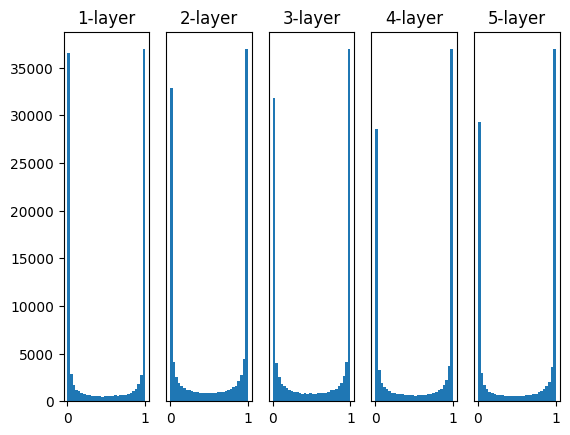

In [135]:
get_histogram(activations)

Gradient vanishing : 기울기 소실

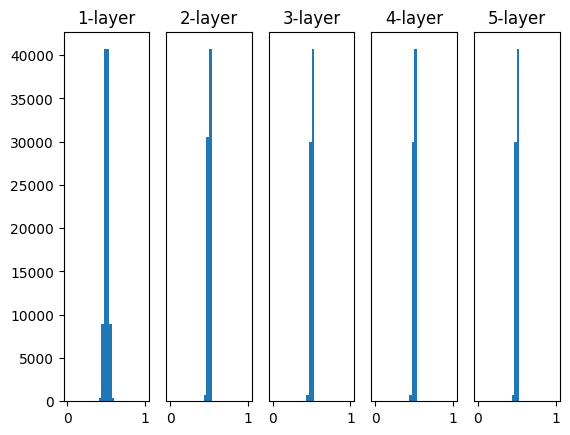

In [136]:
w = np.random.randn(node_num, node_num) * 0.01
activations = get_activation(hidden_layer_size, x, w, z)
get_histogram(activations)

표현력 제한 문제

# Xavier 초기값 사용

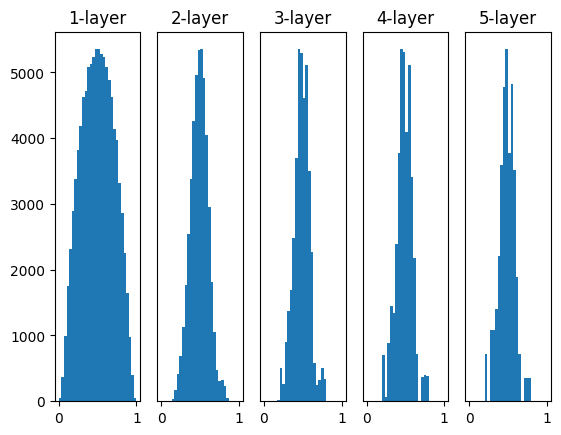

In [137]:
w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
activations = get_activation(hidden_layer_size, x, w, z)
get_histogram(activations)

# He 초기값

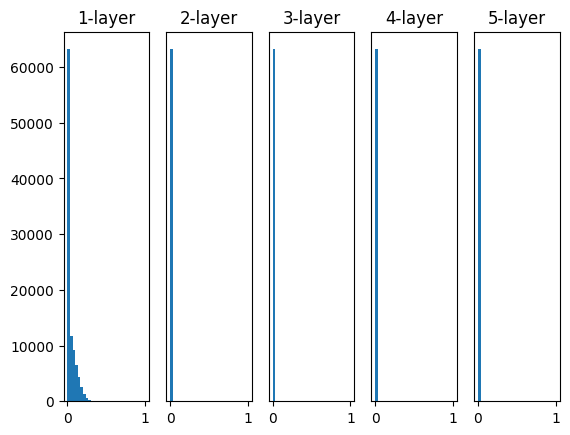

In [138]:
w = np.random.randn(node_num, node_num) * 0.01
z = ReLU
activations = get_activation(hidden_layer_size, x, w, z)
get_histogram(activations)

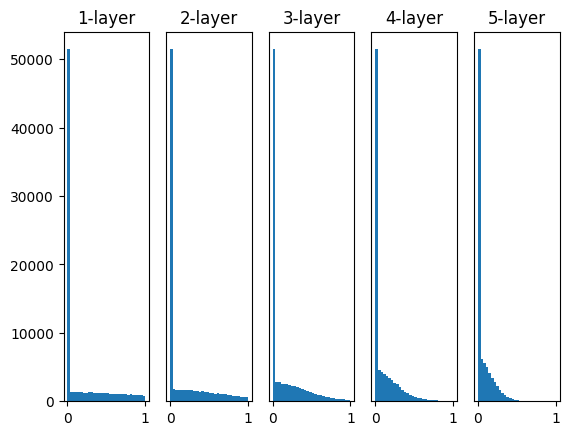

In [139]:
w = np.random.randn(node_num, node_num) * np.sqrt(1.0 / node_num)
activations = get_activation(hidden_layer_size, x, w, z)
get_histogram(activations)

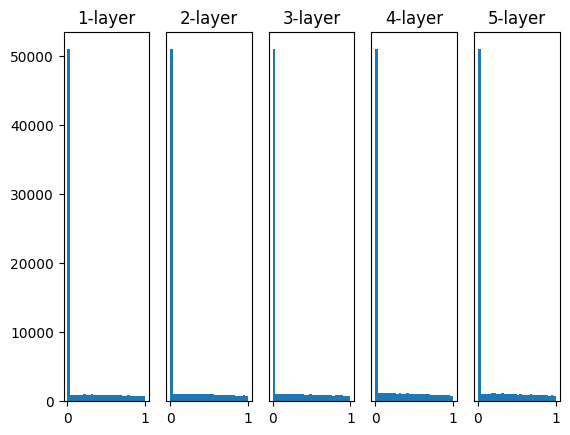

In [140]:
w = np.random.randn(node_num, node_num) * np.sqrt(2.0 / node_num)
activations = get_activation(hidden_layer_size, x, w, z)
get_histogram(activations)

ReLU --> He 초기값

In [141]:
from drive.MyDrive.data.mnistdata.mnist import load_mnist
from drive.MyDrive.data.util import smooth_curve
from drive.MyDrive.data.multi_layer_net import MultiLayerNet
from drive.MyDrive.data.optimizer import SGD

In [142]:
train_size = x_train.shape[0]
batch_size = 128
max_iterations = 2000

In [143]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

In [144]:
x_train.shape, t_train.shape, x_test.shape, t_test.shape

((60000, 784), (60000,), (10000, 784), (10000,))

In [145]:
weight_init_types = {
    'std=0.01':0.01,
    'Xavier':'sigmoid',
    'He':'relu'
}
optimizer = SGD(lr = 0.01)

In [146]:
networks = {}
train_loss = {}
for key, weight_type in weight_init_types.items():
    networks[key] = MultiLayerNet(input_size=784, hidden_size_list=[100, 100, 100, 100],
                                  output_size=10, weight_init_std=weight_type)
    train_loss[key] = []

-----iteration: 0-----
std=0.01 : 2.3025509987316735
Xavier : 2.308485481667831
He : 2.373627380677105
-----iteration: 100-----
std=0.01 : 2.3031267138131453
Xavier : 2.2412726171555333
He : 1.2371923350227276
-----iteration: 200-----
std=0.01 : 2.2979366603342295
Xavier : 2.035265662765877
He : 0.44118154410482696
-----iteration: 300-----
std=0.01 : 2.2974563072913874
Xavier : 1.6669349552582464
He : 0.2792367416513961
-----iteration: 400-----
std=0.01 : 2.2944491780966882
Xavier : 1.0828067844153697
He : 0.18316188018965332
-----iteration: 500-----
std=0.01 : 2.292884971781386
Xavier : 0.6372471952449197
He : 0.09770358150758426
-----iteration: 600-----
std=0.01 : 2.2824896207057144
Xavier : 0.36597579386588236
He : 0.051513754098497455
-----iteration: 700-----
std=0.01 : 2.306548466490656
Xavier : 0.29505780824576866
He : 0.042673907961199437
-----iteration: 800-----
std=0.01 : 2.299173156176505
Xavier : 0.21434382608299415
He : 0.03357727910912585
-----iteration: 900-----
std=0.01 

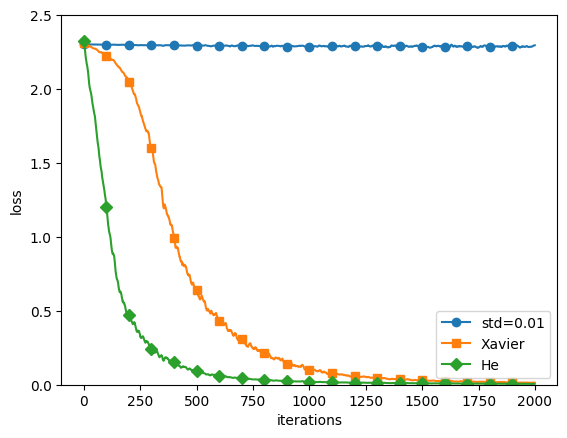

In [147]:
for i in range(max_iterations):
    batch_mask = np.random.choice(train_size, batch_size)
    x_batch = x_train[batch_mask]
    t_batch = t_train[batch_mask]

    for key in weight_init_types.keys():
        grads = networks[key].gradient(x_batch, t_batch)
        optimizer.update(networks[key].params, grads)
        loss = networks[key].loss(x_batch, t_batch)
        train_loss[key].append(loss)

    if i % 100 == 0:
        print('-----' + 'iteration: '+ str(i) + '-----')
        for key in weight_init_types.keys():
            loss = networks[key].loss(x_batch, t_batch)
            print(key + ' : ' + str(loss))

markers = {'std=0.01': 'o', 'Xavier': 's', 'He': 'D'}
x = np.arange(max_iterations)
for key in weight_init_types.keys():
    plt.plot(x, smooth_curve(train_loss[key]), marker=markers[key], markevery=100, label=key)
plt.xlabel("iterations")
plt.ylabel("loss")
plt.ylim(0, 2.5)
plt.legend()
plt.show()

# 배치 정규화

: 데이터 분포가 평균이 0, 분산이 1이 되도록 정규화

# Dropout

: 노드를 임의로 삭제하고 학습하는 방법

In [148]:
from drive.MyDrive.data.multi_layer_net_extend import MultiLayerNetExtend
from drive.MyDrive.data.trainer import Trainer

In [149]:
class Dropout:
    def __init__(self, dropout_ratio=0.15):
        self.dropout_ratio = dropout_ratio
        self.mask = None

    def forward(self, x, train_flg=True):
        if train_flg:
            self.mask = np.random.rand(*x.shape) > self.dropout_ratio
            return x*self.mask

        else:
            return x*(1.0 - self.dropout_ratio)

    def backward(self, dout):
        return dout*self.mask

In [150]:
(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True)

In [151]:
x_train.shape, t_train.shape, x_test.shape, t_test.shape

((60000, 784), (60000,), (10000, 784), (10000,))

In [152]:
x_train = x_train[:300]
t_train = t_train[:300]

In [153]:
x_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [154]:
t_train

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4, 3, 5, 3, 6, 1, 7, 2, 8, 6, 9, 4, 0,
       9, 1, 1, 2, 4, 3, 2, 7, 3, 8, 6, 9, 0, 5, 6, 0, 7, 6, 1, 8, 7, 9,
       3, 9, 8, 5, 9, 3, 3, 0, 7, 4, 9, 8, 0, 9, 4, 1, 4, 4, 6, 0, 4, 5,
       6, 1, 0, 0, 1, 7, 1, 6, 3, 0, 2, 1, 1, 7, 9, 0, 2, 6, 7, 8, 3, 9,
       0, 4, 6, 7, 4, 6, 8, 0, 7, 8, 3, 1, 5, 7, 1, 7, 1, 1, 6, 3, 0, 2,
       9, 3, 1, 1, 0, 4, 9, 2, 0, 0, 2, 0, 2, 7, 1, 8, 6, 4, 1, 6, 3, 4,
       5, 9, 1, 3, 3, 8, 5, 4, 7, 7, 4, 2, 8, 5, 8, 6, 7, 3, 4, 6, 1, 9,
       9, 6, 0, 3, 7, 2, 8, 2, 9, 4, 4, 6, 4, 9, 7, 0, 9, 2, 9, 5, 1, 5,
       9, 1, 2, 3, 2, 3, 5, 9, 1, 7, 6, 2, 8, 2, 2, 5, 0, 7, 4, 9, 7, 8,
       3, 2, 1, 1, 8, 3, 6, 1, 0, 3, 1, 0, 0, 1, 7, 2, 7, 3, 0, 4, 6, 5,
       2, 6, 4, 7, 1, 8, 9, 9, 3, 0, 7, 1, 0, 2, 0, 3, 5, 4, 6, 5, 8, 6,
       3, 7, 5, 8, 0, 9, 1, 0, 3, 1, 2, 2, 3, 3, 6, 4, 7, 5, 0, 6, 2, 7,
       9, 8, 5, 9, 2, 1, 1, 4, 4, 5, 6, 4, 1, 2, 5, 3, 9, 3, 9, 0, 5, 9,
       6, 5, 7, 4, 1, 3, 4, 0, 4, 8, 0, 4, 3, 6], d

In [155]:
x_train.shape, t_train.shape

((300, 784), (300,))

In [156]:
use_dropout=False
dropout_ratio=0.2